<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-I/blob/main/Clase%20009/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Coderhouse - Data Science
Profe Jorge Ruiz

# Segmentación o clasificación de clientes :

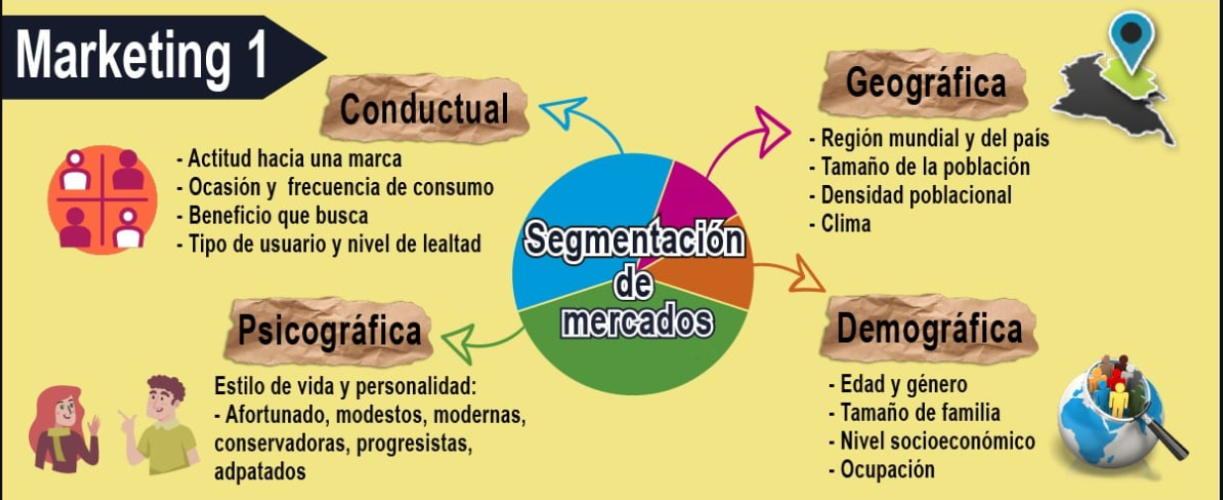

Dentro de machine learning (ML), se encuentran los algoritmos no supervisados que permiten hacer grupos en los datos (clusters) teniendo en cuenta ciertas características y agrupándolos según lo similar que estas sean.

Algoritmo K-Means

El objetivo de K-Means es agrupar observaciones similares para descubrir patrones que a simple vista se desconocen. Para conseguirlo, el algoritmo busca un número fijo (k) de clústers en el dataset.

Este número k es un hiperparámetro del algoritmo. Representa el número de centroides (centro del clúster) que queremos encontrar en el dataset. Para saber qué k tenemos que coger utilizamos la regla del codo.

El algoritmo intenta minimizar la distancia entre las observaciones que pertenecen a un clúster y su centroide. Es decir, el objetivo del K-Means es minimizar la suma de las distancias entre los puntos y el centroide al que pertenecen.

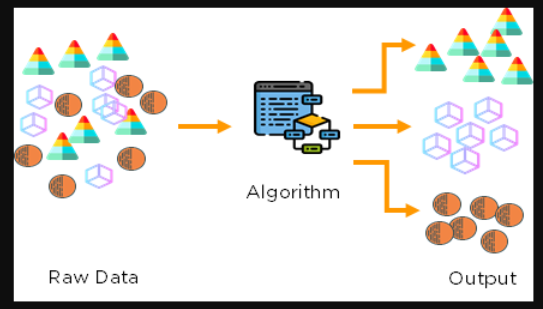

En marketing este tipo de modelos son una poderosa herramienta ya que permite realizar campañas focalizadas a un grupo de clientes e inclusive tomar múltiples decisiones, como tratar de llevar personas de un cluster a otro donde sea más rentable para el negocio.

Problema inicial:

Un supermercado (sector retail) desea segmentar a sus clientes en categorías mediante ciertas características conocidas.




In [ ]:
# se importan las librerias necesarias
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
#se importa el set de datos
df_final = pd.read_csv('Mall_Customers.csv', sep=",")
df_final.head()


In [ ]:
# No usemos genero pero si el score interno.
df_final.drop(columns=["Gender", "CustomerID"], inplace=True)
df_final.head()

Elección de k con la regla del codo

Para elegir el número de clústers idóneos  se hace varias ejecuciones con k diferentes (desde 1 clúster hasta 12) y representaremos en un gráfico la distancia media de cada punto hasta su centroide y el tiempo de entrenamiento necesario.

La idea es que a medida que vamos aumentando la cantidad de centroides, la distancia media de los puntos al centroide irá disminuyendo cada vez menos. La norma  mnemotecnia  es la norma del codo puesto que la gráfica es una curva y el número de clústers óptimo será el ‘codo’ del brazo.

La librería yellowbrick tiene un método rápido para visualizar esto.

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12))
visualizer.fit(df_final)        # Entrenamos con los datos
visualizer.show()        # Renderizamos la imagen

# se recomienda leer https://www.scikit-yb.org/en/latest/api/cluster/elbow.html

In [ ]:
from sklearn.preprocessing import StandardScaler


# Estandarizar los datos
scaler = StandardScaler()
# los datos deben ser estandarizados ya que al tener las variables de entrada de diferente naturaleza, puede generar ruido en la segmentación.
df_final_scaled = scaler.fit_transform(df_final)
df_final_scaled

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12))
visualizer.fit(df_final_scaled)        # Entrenamos con los datos
visualizer.show()

In [ ]:
# Crear y ajustar el modelo K-means
modelo = KMeans(n_clusters=4, max_iter=1000, init='random', random_state=42)
preds = modelo.fit_predict(df_final_scaled)

# revisar https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

Escalado de los datos: se utiliza el objeto StandardScaler para estandarizar los datos, es decir, para transformar las características de forma que tengan una media de cero y una desviación estándar de uno.  

Clustering con K-Means: se utiliza el algoritmo de K-Means para agrupar los datos en un número predefinido de clústeres. En este caso, se define n_clusters=5 para indicar que se desean 5 clústeres. Además, se establece un límite máximo de iteraciones (max_iter=1000) y se utiliza la inicialización aleatoria de los centroides (init='random')



In [ ]:
type(preds)

In [ ]:
df_final

In [ ]:
preds

In [ ]:
import numpy as np
np.ndim(preds)

In [ ]:
modelo

In [ ]:

import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


from mpl_toolkits.mplot3d import axes3d

fig = plt.figure(figsize=(10,7))
ax = plt.axes(projection="3d")
ax.scatter3D(df_final["Annual Income (k$)"], df_final["Age"], df_final["Spending Score (1-100)"], c=preds, cmap="tab10")
plt.title("Mall Clusters")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Age")
ax.set_zlabel("Spending Score (1-100)")
plt.show()

In [ ]:
preds=pd.DataFrame(preds)
preds

In [ ]:
df_concat=pd.concat([df_final, preds], axis=1)
df_concat

In [ ]:
df_concat=df_concat.rename(columns = {0:'cluster'})
df_concat

In [ ]:
df_concat.groupby(["cluster"])[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].describe()

In [ ]:
cluster_0 = df_concat[df_concat.cluster.isin([0])]
cluster_1 = df_concat[df_concat.cluster.isin([1])]
cluster_2 = df_concat[df_concat.cluster.isin([2])]
cluster_3 = df_concat[df_concat.cluster.isin([3])]
cluster_4 = df_concat[df_concat.cluster.isin([4])]

In [ ]:
%matplotlib inline
plt.figure(figsize=(20,10))
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

boxplot= sns.boxplot(data=[cluster_0["Age"], cluster_1["Age"], cluster_2["Age"], cluster_3["Age"], cluster_4["Age"]], orient="h", palette="Set2")
boxplot.axes.set_title("Distribución de la edad en los diferentes clusters", fontsize=20)
boxplot.set_xlabel("Edad", fontsize=18)
boxplot.set_ylabel("Clusters", fontsize=18)
plt.show()

# Ideas para analizar, por ejemplo:

1) La gente joven tiende a tener buen score, sin depender tanto de su salario, pero hay personas menores a 40 años con score bajo.

2) Las personas de ingresos altos y medios de más de 40 años tienen en su mayoría un score bajo. Pero hay un claro grupo que tiene personas superiores a los 40 años y tienen un score medio.